# 02 · Generate the processed datasets

**Phase 3** of the pipeline, in **comparative** mode.

Three techniques, three parameter settings each, so nine datasets. Each one is
a complete, self-contained copy of the dataset — same 693 images, same labels,
only the pixels differ. Each is trained separately and the results compared,
which is what the comparative study requires.

| Key | Technique | Setting |
|-----|-----------|---------|
| A1 A2 A3 | Gaussian filtering | light / medium / heavy |
| B1 B2 B3 | Canny-guided edge enhancement | weak / medium / strong |
| C1 C2 C3 | Morphological enhancement | small / medium / large |

**Disk needed: about 8.6 GB for all nine.** Build them one at a time if space
is short.

## 1 · Setup

In [2]:
# ---------------------------------------------------------------------
# Locate the project root.
#
# This notebook may sit in notebook/, or in notebook/<yourname>/, so the
# search walks upwards until it finds the folder containing "data".
# Every path below is built from PROJECT_ROOT, so nothing breaks when the
# notebook is moved or when a teammate runs it on a different machine.
# ---------------------------------------------------------------------
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "data").is_dir():
    raise SystemExit(
        "Could not find the project root (a folder containing 'data').\n"
        "Set PROJECT_ROOT manually, for example:\n"
        "    PROJECT_ROOT = Path(r'C:/Users/you/PCB-Defect-Inspection')")

RAW_DIR       = PROJECT_ROOT / "data" / "raw"        # Annotations + images
YOLO_DIR      = PROJECT_ROOT / "data" / "yolo"       # generated in notebook 01
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"  # generated in notebook 02
RUNS_DIR      = PROJECT_ROOT / "runs" / "pcb_comparison"

print("Project root :", PROJECT_ROOT)
print("Raw data     :", RAW_DIR, "  exists:", RAW_DIR.is_dir())

Project root : e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection
Raw data     : e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\raw   exists: True


In [3]:
import shutil
import time
from concurrent.futures import ThreadPoolExecutor

import cv2
import numpy as np
import matplotlib.pyplot as plt

SPLITS = ["train", "val", "test"]

# Re-saving a JPEG always loses a little quality. 95 keeps that loss far
# below the changes the processing itself makes, so it cannot confound
# the comparison.
JPEG_QUALITY = 95

# Threads rather than processes: a process pool cannot pickle functions
# defined in a notebook cell on Windows, so it fails there. Most OpenCV
# calls release the GIL, so threads still give a real speed-up.
WORKERS = 4

if not (YOLO_DIR / "data.yaml").exists():
    raise SystemExit("Run 01_build_yolo_dataset.ipynb first.")

print("Source dataset :", YOLO_DIR)
print("Output folder  :", PROCESSED_DIR)

Source dataset : e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\yolo
Output folder  : e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed


## 2 · The three techniques

Two rules apply to every function below. Breaking either invalidates the whole
experiment.

**The output stays in colour.** It is tempting to feed YOLO a raw Canny edge
map, but an edge map throws away colour and texture. Reduced to edges,
*missing_hole* and *mouse_bite* are both simply a break in a boundary, and the
network has nothing left to tell them apart. Each technique therefore
**enhances** the photograph rather than replacing it.

**The image size never changes.** YOLO labels are fractions of the image width
and height. Nothing here crops, resizes or rotates, so the label files copy
across unchanged. Any step that alters the geometry would require transforming
the labels to match.

In [4]:
def gaussian_filter(image, ksize, sigma):
    """A. Gaussian filtering - suppress noise before detection.

    Each pixel becomes a weighted average of its neighbours, the weights
    following a bell curve, so random sensor noise averages out. The
    trade-off is the point of the experiment: a larger kernel removes more
    noise but also blurs the fine copper tracks that define the defects.
    """
    return cv2.GaussianBlur(image, (ksize, ksize), sigma)


def canny_edge_enhance(image, low, high, weight):
    """B. Canny-guided edge enhancement - make boundaries more prominent.

    Canny locates the copper boundaries, and those boundaries are blended
    back into the original photograph as a brightness boost. Every defect
    in this dataset is a boundary deformation (a bitten edge, a severed
    track, an added spur), so strengthening boundaries should help.

    The colour image survives intact underneath, which is what separates
    this from feeding YOLO the bare edge map.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 1.0)   # keeps Canny off JPEG noise
    edges = cv2.Canny(gray, low, high, L2gradient=True)

    # Thicken the one-pixel contours, or the boost vanishes when the image
    # is later scaled down to the network input size.
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8))

    # Adding equally to all three channels brightens the boundaries without
    # shifting the hue of the board.
    edge_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
    return cv2.addWeighted(image, 1.0, edge_bgr, weight, 0)


def morphological_enhance(image, ksize):
    """C. Morphological enhancement - increase local contrast.

        enhanced = original + tophat - blackhat

    Top hat isolates small BRIGHT features (silver pads and tracks), black
    hat isolates small DARK features (drill holes, gaps). Adding one and
    subtracting the other pushes them apart, so copper stands out from the
    solder mask.

    The work happens on the L (lightness) channel of LAB rather than on
    B, G and R directly. Applying it per channel would change the ratios
    between them and shift the board's colour; LAB keeps lightness and
    colour separate, so only brightness moves.

    ksize matters more here than elsewhere, because each operation only
    detects features SMALLER than its structuring element.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    lightness = lab[:, :, 0]

    tophat = cv2.morphologyEx(lightness, cv2.MORPH_TOPHAT, kernel)
    blackhat = cv2.morphologyEx(lightness, cv2.MORPH_BLACKHAT, kernel)

    # int16 prevents the wrap-around that uint8 would suffer if a value
    # went below 0 or above 255 during the arithmetic.
    enhanced = (lightness.astype(np.int16)
                + tophat.astype(np.int16)
                - blackhat.astype(np.int16))
    lab[:, :, 0] = np.clip(enhanced, 0, 255).astype(np.uint8)

    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


print("Processing functions defined.")

Processing functions defined.


## 3 · The nine configurations

Values come from the Phase 2 parameter study. Edit them here rather than
inside the functions, so every run is reproducible from this one table.

In [5]:
CONFIGS = {
    # --- A. Gaussian filtering, three smoothing strengths -------------
    "A1": ("Gaussian", "light  (k=3,  sigma=0.8)",
           gaussian_filter, {"ksize": 3, "sigma": 0.8}),
    "A2": ("Gaussian", "medium (k=5,  sigma=1.5)",
           gaussian_filter, {"ksize": 5, "sigma": 1.5}),
    "A3": ("Gaussian", "heavy  (k=9,  sigma=2.5)",
           gaussian_filter, {"ksize": 9, "sigma": 2.5}),

    # --- B. Canny-guided edge enhancement, three boost strengths ------
    "B1": ("Canny edge", "weak   (100/200, w=0.3)",
           canny_edge_enhance, {"low": 100, "high": 200, "weight": 0.3}),
    "B2": ("Canny edge", "medium (50/150,  w=0.5)",
           canny_edge_enhance, {"low": 50, "high": 150, "weight": 0.5}),
    "B3": ("Canny edge", "strong (30/90,   w=0.7)",
           canny_edge_enhance, {"low": 30, "high": 90, "weight": 0.7}),

    # --- C. Morphological enhancement, three element sizes ------------
    "C1": ("Morphological", "small  (k=5)",
           morphological_enhance, {"ksize": 5}),
    "C2": ("Morphological", "medium (k=15)",
           morphological_enhance, {"ksize": 15}),
    "C3": ("Morphological", "large  (k=25)",
           morphological_enhance, {"ksize": 25}),
}

print(f"{'key':<6}{'technique':<16}setting")
print("-" * 60)
for key, (technique, setting, _, _) in CONFIGS.items():
    print(f"{key:<6}{technique:<16}{setting}")

key   technique       setting
------------------------------------------------------------
A1    Gaussian        light  (k=3,  sigma=0.8)
A2    Gaussian        medium (k=5,  sigma=1.5)
A3    Gaussian        heavy  (k=9,  sigma=2.5)
B1    Canny edge      weak   (100/200, w=0.3)
B2    Canny edge      medium (50/150,  w=0.5)
B3    Canny edge      strong (30/90,   w=0.7)
C1    Morphological   small  (k=5)
C2    Morphological   medium (k=15)
C3    Morphological   large  (k=25)


## 4 · Build one dataset

In [6]:
def build_dataset(config_key, limit=0):
    """Create one complete processed dataset for a single configuration."""
    technique, setting, function, kwargs = CONFIGS[config_key]
    output_root = PROCESSED_DIR / f"pcb_{config_key}"

    print(f"\n{'=' * 68}")
    print(f"{config_key}: {technique} - {setting}")
    print(f"{'=' * 68}")

    jobs, label_count = [], 0

    for split in SPLITS:
        (output_root / "images" / split).mkdir(parents=True, exist_ok=True)
        (output_root / "labels" / split).mkdir(parents=True, exist_ok=True)

        images = sorted((YOLO_DIR / "images" / split).glob("*.jpg"))
        if limit:
            images = images[:limit]

        for image_path in images:
            jobs.append((image_path,
                         output_root / "images" / split / image_path.name))

            # THE LABELS ARE COPIED WITHOUT MODIFICATION.
            # None of the techniques moves a pixel, so a defect sits at
            # exactly the same coordinates before and after processing.
            label_path = YOLO_DIR / "labels" / split / f"{image_path.stem}.txt"
            if label_path.exists():
                shutil.copy2(label_path,
                             output_root / "labels" / split / label_path.name)
                label_count += 1

    # EVERY SPLIT GETS THE SAME PROCESSING.
    # Processing only the training images would leave the network trained on
    # enhanced pictures but validated and tested on unenhanced ones. The
    # mismatch would depress the scores for reasons that have nothing to do
    # with whether the technique works.

    problems = []

    def run_one(job):
        source_path, destination_path = job
        image = cv2.imread(str(source_path), cv2.IMREAD_COLOR)
        if image is None:
            return f"unreadable: {source_path.name}"

        result = function(image, **kwargs)

        # Checked, not assumed: if this ever failed, every label would
        # silently stop matching its image.
        if result.shape != image.shape:
            return (f"SHAPE CHANGED: {source_path.name} "
                    f"{image.shape} -> {result.shape}")

        cv2.imwrite(str(destination_path), result,
                    [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])
        return None

    start = time.time()
    with ThreadPoolExecutor(max_workers=WORKERS) as pool:
        for i, message in enumerate(pool.map(run_one, jobs), 1):
            if message:
                problems.append(message)
            if i % 50 == 0 or i == len(jobs):
                print(f"   {i}/{len(jobs)} images", end="\r")
    elapsed = time.time() - start

    # data.yaml: identical classes to the baseline, only the path changes.
    # The settings are recorded in a comment so any result can be traced
    # back to the parameters that produced it.
    (output_root / "data.yaml").write_text(f"""# data.yaml - processed dataset {config_key}
#   technique  : {technique}
#   setting    : {setting}
#   parameters : {kwargs}
# Generated by 02_processed_dataset.ipynb

path: {output_root.resolve()}

train: images/train
val:   images/val
test:  images/test

nc: 6

names:
  0: missing_hole
  1: mouse_bite
  2: open_circuit
  3: short
  4: spur
  5: spurious_copper
""")

    print(f"   {len(jobs)} images, {label_count} labels, {elapsed:.1f}s "
          f"({elapsed / max(len(jobs), 1):.2f}s each)")
    print(f"   -> {output_root}")

    if problems:
        print(f"   WARNING - {len(problems)} problem(s)")
        for message in problems[:5]:
            print("      " + message)

    return problems


print("build_dataset() defined.")

build_dataset() defined.


In [7]:
import itertools

def gaussian_then_canny(image, ksize, sigma, low, high, weight):
    """Combined: Gaussian smoothing, then Canny-guided edge enhancement.

    Order is deliberate — denoise first, then strengthen boundaries. The
    reverse would blur the edge overlay just added.

    Note the two stages interact: heavier smoothing leaves fewer gradients
    for Canny to find, so the edge overlay shrinks as ksize/sigma rise.
    The grid is therefore not orthogonal.
    """
    smoothed = cv2.GaussianBlur(image, (ksize, ksize), sigma)
    return canny_edge_enhance(smoothed, low, high, weight)


# Reuse the exact parameters from the single-technique configs, so any
# difference is attributable to the combination rather than to retuning.
GAUSS_PARAMS = {"A1": {"ksize": 3, "sigma": 0.8},
                "A2": {"ksize": 5, "sigma": 1.5},
                "A3": {"ksize": 9, "sigma": 2.5}}

CANNY_PARAMS = {"B1": {"low": 100, "high": 200, "weight": 0.3},
                "B2": {"low": 50,  "high": 150, "weight": 0.5},
                "B3": {"low": 30,  "high": 90,  "weight": 0.7}}

COMBINED_KEYS = []
for g, c in itertools.product(GAUSS_PARAMS, CANNY_PARAMS):
    key = f"{g}{c}"                      # A1B1, A1B2, ... A3B3
    CONFIGS[key] = ("Combined", f"{g} + {c}",
                    gaussian_then_canny,
                    {**GAUSS_PARAMS[g], **CANNY_PARAMS[c]})
    COMBINED_KEYS.append(key)

print(f"Added {len(COMBINED_KEYS)} combined configs: {COMBINED_KEYS}")

Added 9 combined configs: ['A1B1', 'A1B2', 'A1B3', 'A2B1', 'A2B2', 'A2B3', 'A3B1', 'A3B2', 'A3B3']


In [8]:
for key in COMBINED_KEYS:
    build_dataset(key)


A1B1: Combined - A1 + B1
   693 images, 693 labels, 25.9s (0.04s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A1B1

A1B2: Combined - A1 + B2
   693 images, 693 labels, 25.8s (0.04s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A1B2

A1B3: Combined - A1 + B3
   693 images, 693 labels, 41.1s (0.06s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A1B3

A2B1: Combined - A2 + B1
   693 images, 693 labels, 23.9s (0.03s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A2B1

A2B2: Combined - A2 + B2
   693 images, 693 labels, 24.3s (0.04s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A2B2

A2B3: Combined - A2 + B3
   693 images, 693 labels, 45.6s (0.07s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A2B3

A3B1: Combined - A3 + B1
   693 images, 693 l

## 5 · Smoke test

Three images per split first. This takes seconds and catches any mistake
before committing 8.6 GB and half an hour to it.

In [10]:
smoke_problems = []
for key in CONFIGS:
    smoke_problems.extend(build_dataset(key, limit=3))

print(f"\n{'=' * 68}")
print("Smoke test problems:", len(smoke_problems))


A1: Gaussian - light  (k=3,  sigma=0.8)
   9 images, 9 labels, 0.3s (0.03s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A1

A2: Gaussian - medium (k=5,  sigma=1.5)
   9 images, 9 labels, 0.2s (0.02s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A2

A3: Gaussian - heavy  (k=9,  sigma=2.5)
   9 images, 9 labels, 0.2s (0.02s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A3

B1: Canny edge - weak   (100/200, w=0.3)
   9 images, 9 labels, 0.4s (0.04s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_B1

B2: Canny edge - medium (50/150,  w=0.5)
   9 images, 9 labels, 0.4s (0.04s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_B2

B3: Canny edge - strong (30/90,   w=0.7)
   9 images, 9 labels, 0.4s (0.04s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pc

## 6 · Check the smoke-test output before the full run

In [9]:
print(f"{'cfg':<5}{'imgs':>6}{'labels':>8}{'shape kept':>12}"
      f"{'labels identical':>18}{'mean pixel delta':>18}")

for key in CONFIGS:
    root = PROCESSED_DIR / f"pcb_{key}"
    images = sorted(root.glob("images/*/*.jpg"))
    labels = sorted(root.glob("labels/*/*.txt"))

    shape_ok, labels_ok, deltas = True, True, []

    for path in images:
        original = cv2.imread(str(YOLO_DIR / "images" / path.parent.name / path.name))
        processed = cv2.imread(str(path))
        if original.shape != processed.shape:
            shape_ok = False
        else:
            deltas.append(float(np.abs(original.astype(np.int16)
                                       - processed.astype(np.int16)).mean()))

    for path in labels:
        source = YOLO_DIR / "labels" / path.parent.name / path.name
        if source.read_text() != path.read_text():
            labels_ok = False

    print(f"{key:<5}{len(images):>6}{len(labels):>8}{str(shape_ok):>12}"
          f"{str(labels_ok):>18}{np.mean(deltas):>18.2f}")

print("\nThe pixel delta should rise within each technique group (A1<A2<A3).")
print("If two settings give nearly the same delta, they will produce nearly")
print("the same model, and comparing them tells you nothing.")

cfg    imgs  labels  shape kept  labels identical  mean pixel delta
A1      693     693        True              True              1.57
A2      693     693        True              True              2.29
A3      693     693        True              True              3.07
B1      693     693        True              True              2.22
B2      693     693        True              True              8.08
B3      693     693        True              True             18.84
C1      693     693        True              True              3.44
C2      693     693        True              True              6.89
C3      693     693        True              True             11.43
A1B1    693     693        True              True              2.44
A1B2    693     693        True              True              7.40
A1B3    693     693        True              True             17.36
A2B1    693     693        True              True              2.65
A2B2    693     693        True              Tru

## 7 · Look at the result at defect scale

A defect is only tens of pixels across, so whole-board views hide what the
processing actually did. This crops one defect and shows every variant.

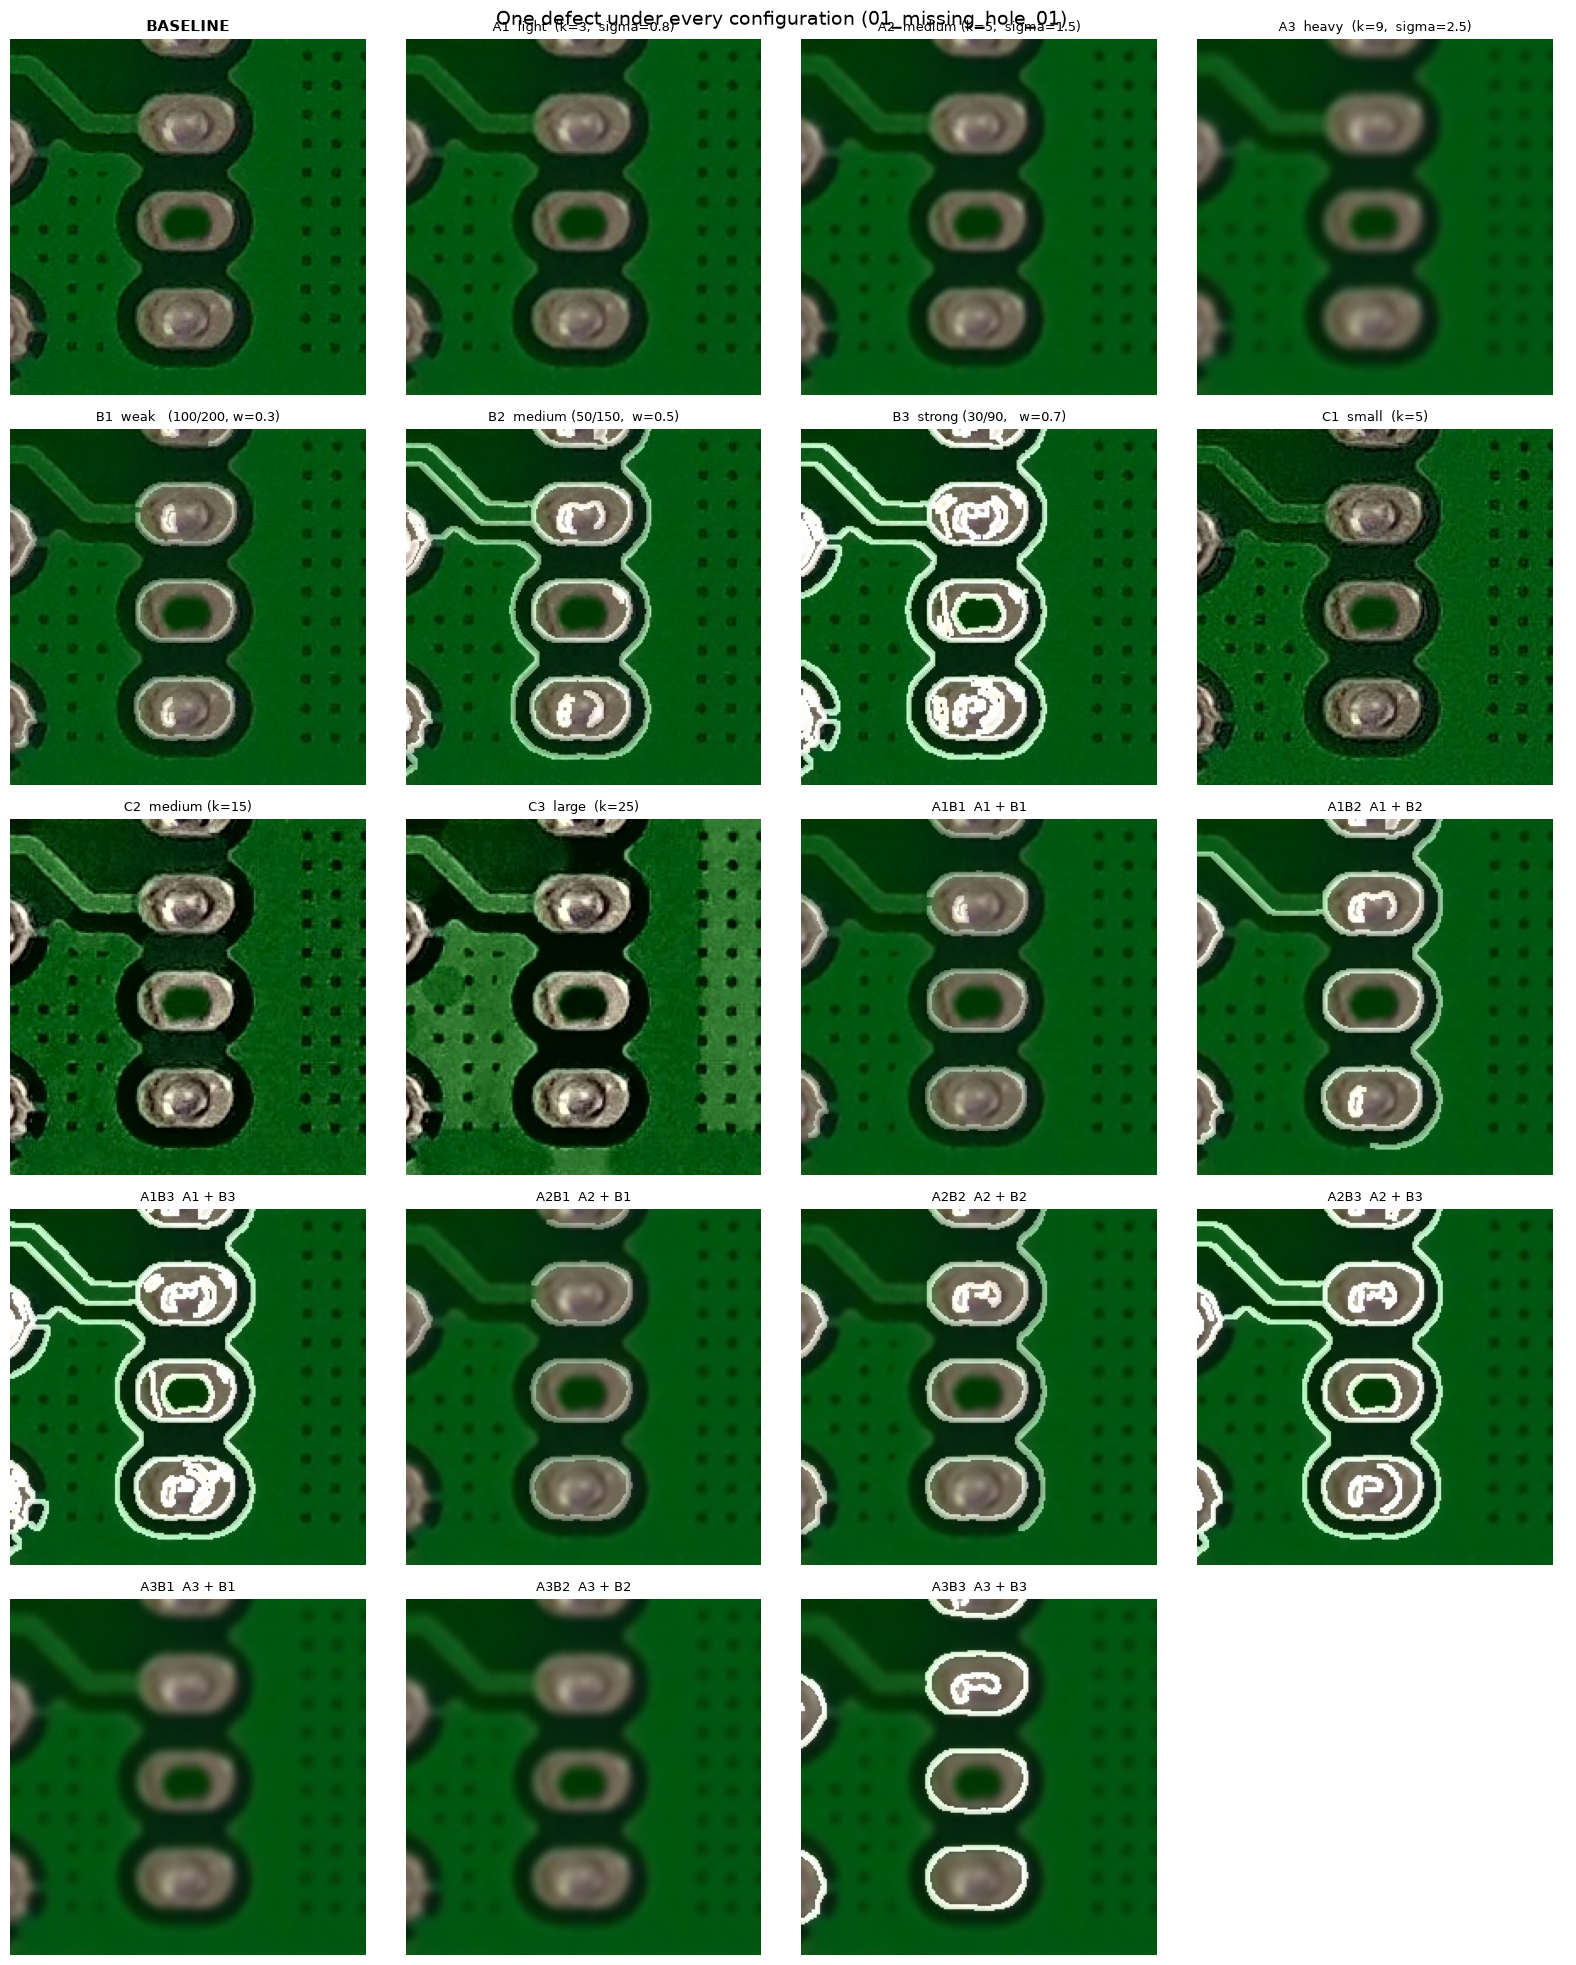

In [10]:
image_path = sorted((YOLO_DIR / "images" / "train").glob("*.jpg"))[0]
label_path = YOLO_DIR / "labels" / "train" / f"{image_path.stem}.txt"

image = cv2.imread(str(image_path))
H, W = image.shape[:2]

_, xc, yc, w, h = label_path.read_text().split("\n")[0].split()
xc, yc = float(xc) * W, float(yc) * H
w, h = float(w) * W, float(h) * H

pad = 70
half = int(max(w, h) / 2 + pad)
y0, y1 = int(yc - half), int(yc + half)
x0, x1 = int(xc - half), int(xc + half)

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
axes = axes.ravel()

axes[0].imshow(cv2.cvtColor(image[y0:y1, x0:x1], cv2.COLOR_BGR2RGB))
axes[0].set_title("BASELINE", fontsize=11, weight="bold")

for ax, key in zip(axes[1:], CONFIGS):
    crop = cv2.imread(str(PROCESSED_DIR / f"pcb_{key}" /
                          "images" / "train" / image_path.name))[y0:y1, x0:x1]
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{key}  {CONFIGS[key][1]}", fontsize=9)

for ax in axes:
    ax.axis("off")

plt.suptitle(f"One defect under every configuration ({image_path.stem})",
             fontsize=14)
plt.tight_layout()
plt.show()

## 8 · The full run

Only run this once section 6 looks right and section 7 shows the processing
doing something sensible.

**About 8.6 GB and 20–40 minutes.** To build a single configuration instead,
call `build_dataset("A1")`.

In [14]:
# Set to True when you are ready to commit the disk space and the time.
RUN_FULL = True

if RUN_FULL:
    all_problems = []
    for key in CONFIGS:
        all_problems.extend(build_dataset(key))

    print(f"\n{'=' * 68}")
    print("Total problems:", len(all_problems))
    for message in all_problems[:10]:
        print("   " + message)
else:
    print("RUN_FULL is False - only the 3-image smoke test has been built.")
    print("Set RUN_FULL = True and re-run this cell for the real datasets.")


A1: Gaussian - light  (k=3,  sigma=0.8)
   693 images, 693 labels, 16.2s (0.02s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A1

A2: Gaussian - medium (k=5,  sigma=1.5)
   693 images, 693 labels, 12.7s (0.02s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A2

A3: Gaussian - heavy  (k=9,  sigma=2.5)
   693 images, 693 labels, 12.5s (0.02s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_A3

B1: Canny edge - weak   (100/200, w=0.3)
   693 images, 693 labels, 27.7s (0.04s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_B1

B2: Canny edge - medium (50/150,  w=0.5)
   693 images, 693 labels, 33.3s (0.05s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\data\processed\pcb_B2

B3: Canny edge - strong (30/90,   w=0.7)
   693 images, 693 labels, 26.8s (0.04s each)
   -> e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defec

---

**Next:** `03_run_comparison.ipynb` trains the baseline plus all nine variants
and ranks them.